In [5]:
%pip install trimesh
%pip install pyembree
%pip install embreex
%pip install "pyglet<2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: C:\Users\shubi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: C:\Users\shubi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: C:\Users\shubi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ------------- -------------------------- 0.4/1.1 MB 12.6 MB/s eta 0:00:01
     ------------------------------ --------- 0.9/1.1 MB 10.9 MB/s eta 0:00:01
     ---------------------------------------- 1.1/1.1 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: pyglet
    Found existing installation: pyglet 2.1.3
    Uninstalling pyglet-2.1.3:
      Successfully uninstalled pyglet-2.1.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: C:\Users\shubi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np

# Finding all ray directions (all directions 3D)
# Convert spherical coordinates to Cartesian coordinates
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)

directions = []
for i in range(len(x)):
    for j in range(len(x[i])):
        directions.append([x[i][j], y[i][j], z[i][j]])
        
print(len(directions))
LiDAR_size = len(directions)

10000


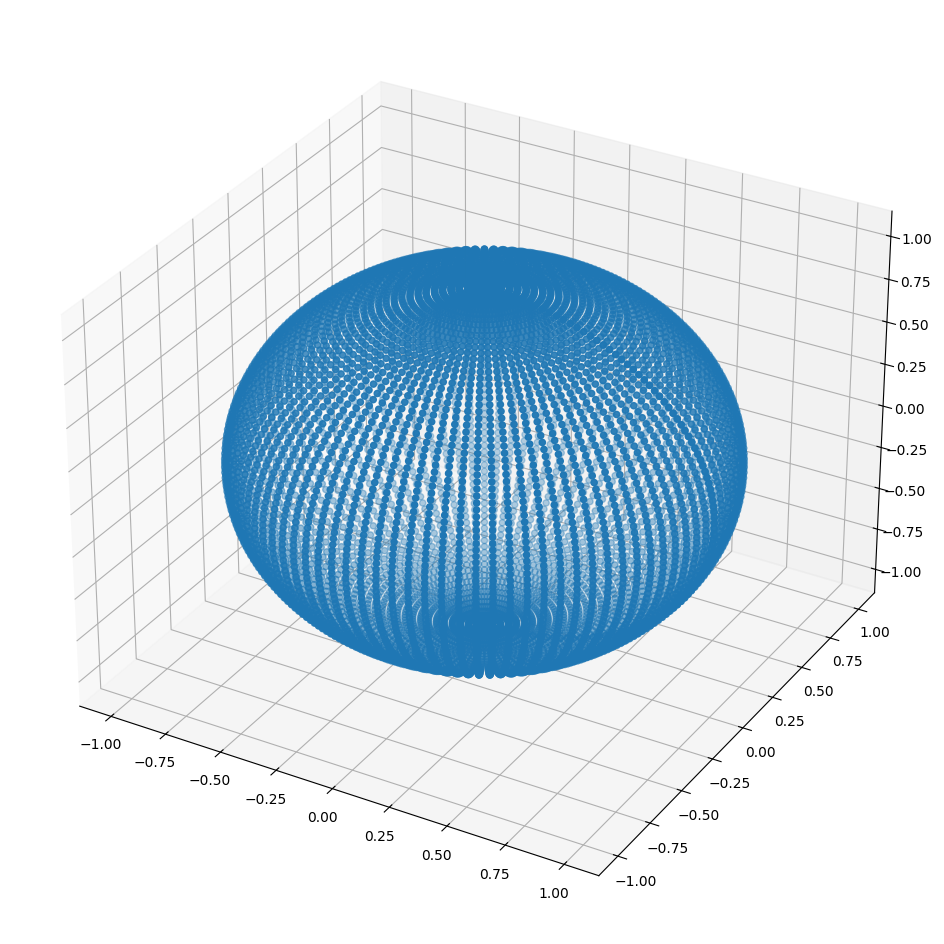

In [2]:
# Testing to make sure that it correctly produces a sphere
import matplotlib.pyplot as plt
import random

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

x = []
y = []
z = []

for dir in directions:
    x.append(dir[0])
    y.append(dir[1])
    z.append(dir[2])

ax.scatter(x, y, z)

plt.show()

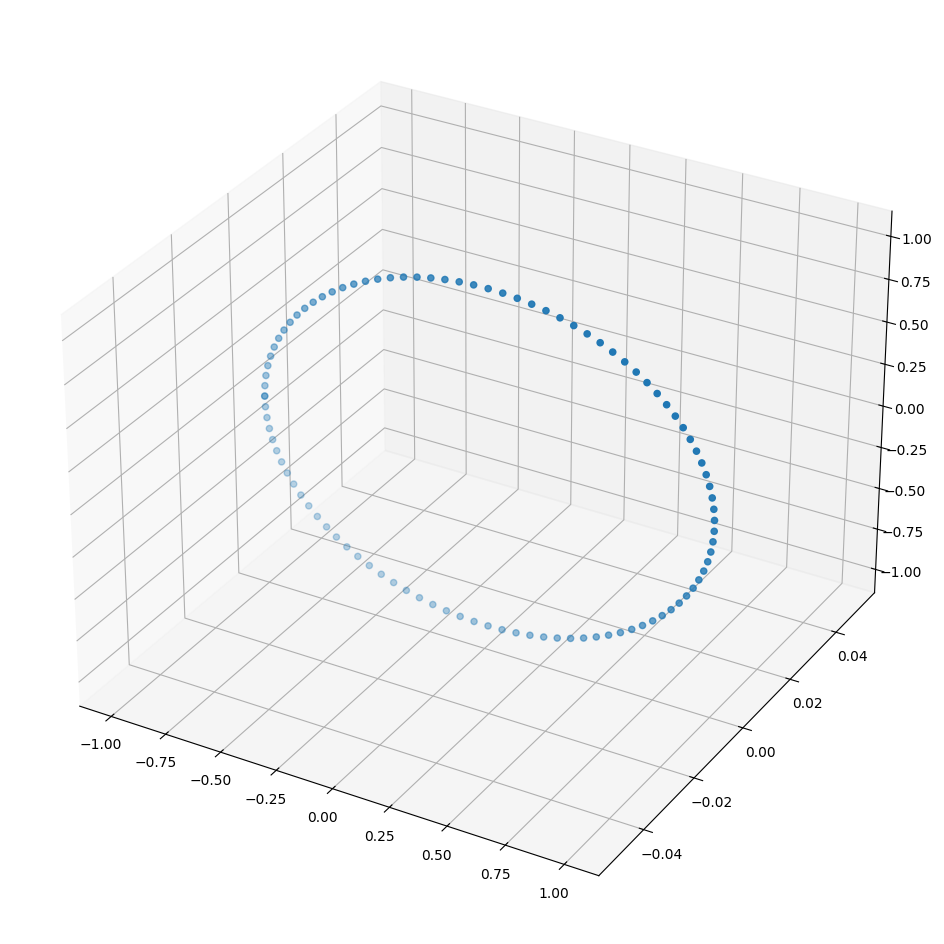

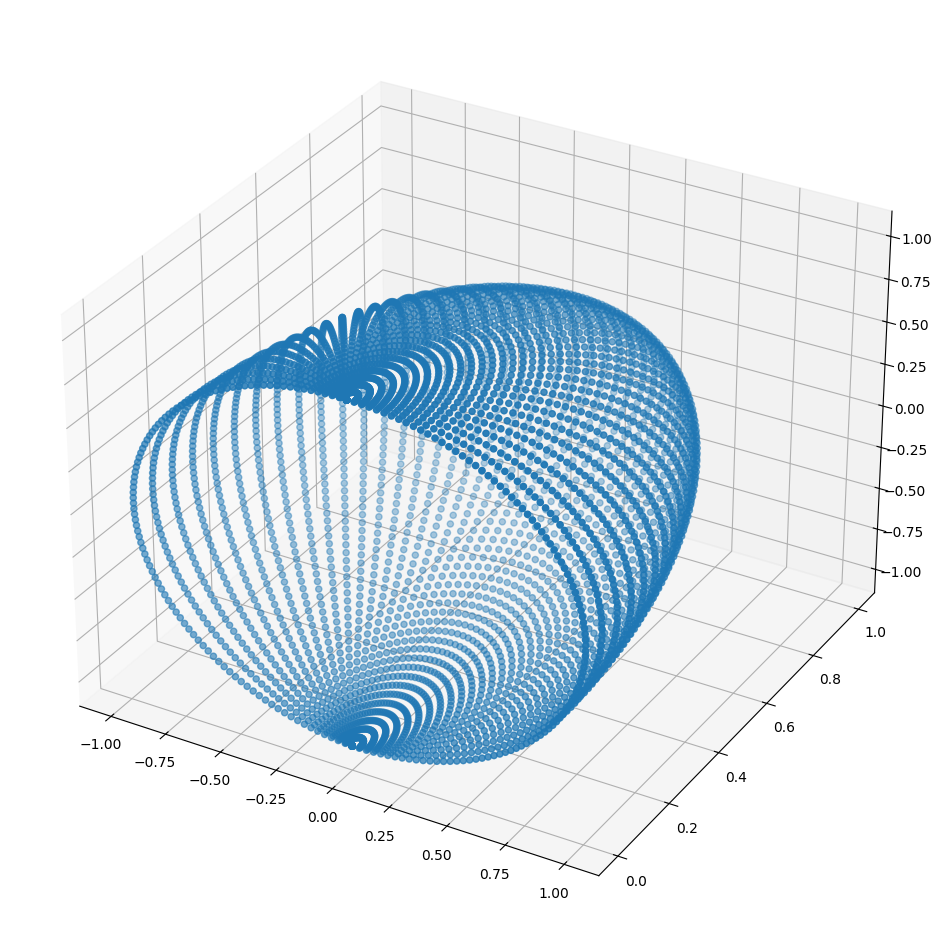

In [3]:
import matplotlib.pyplot as plt
import random
import numpy as np


def create_LiDAR_direction(num, normal_vector, planar=True):
    if (planar):
        return create_LiDAR_direction_2D(num, normal_vector)
    
    u, v = np.mgrid[0:2*np.pi:num*1j, 0:np.pi:num*1j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    
    directions = []
    for i in range(len(x)):
        for j in range(len(x[i])):
            point = np.array([x[i][j], y[i][j], z[i][j]])
            dot = np.dot(point, normal_vector)

            if dot >= 0:  # Keep points in the same hemisphere
                directions.append(point)


    return directions

def create_LiDAR_direction_2D(num, normal_vector):
    # For a complete circle perpendicular to the normal vector:
    
    # Normalize the normal vector
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Create basis vectors for the plane perpendicular to normal_vector
    if abs(normal_vector[0]) < abs(normal_vector[1]) and abs(normal_vector[0]) < abs(normal_vector[2]):
        v1 = np.array([0, -normal_vector[2], normal_vector[1]])
    elif abs(normal_vector[1]) < abs(normal_vector[2]):
        v1 = np.array([-normal_vector[2], 0, normal_vector[0]])
    else:
        v1 = np.array([-normal_vector[1], normal_vector[0], 0])
        
    v1 = v1 / np.linalg.norm(v1)  # Normalize v1
    v2 = np.cross(normal_vector, v1)  # v2 is perpendicular to both normal_vector and v1
    
    # Use linspace with endpoint=True to ensure inclusion of both endpoints
    theta = np.linspace(0, 2*np.pi, num, endpoint=True)
    directions = []
    
    for t in theta:
        point = np.cos(t) * v1 + np.sin(t) * v2
        directions.append(point)
    
    return directions

def show_plot(directions):
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(projection='3d')
    
    x = []
    y = []
    z = []
    
    for dir in directions:
        x.append(dir[0])
        y.append(dir[1])
        z.append(dir[2])
    
    ax.scatter(x, y, z)
    
    plt.show()

show_plot(create_LiDAR_direction(100, [ 0, 1,  0]))
show_plot(create_LiDAR_direction(100, [ 0, 1,  0], False))

In [6]:
import numpy as np

import trimesh
from trimesh.path.entities import Line
from trimesh.path import Path2D, Path3D

from math import tan, sin, cos, sqrt

import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R



dt = 1.0
wheelbase = 0.5
cmds = [np.array([.8, np.random.choice([1, -1]) * .01])] * 20
step = 1
num_LiDAR = 100


def move(x, dt, u, wheelbase):
    hdg = x[2]
    vel = u[0]
    steering_angle = u[1]
    dist = vel * dt
    if abs(steering_angle) > 0.001: # is robot turning?
        beta = (dist / wheelbase) * tan(steering_angle)
        r = wheelbase / tan(steering_angle) # radius
        sinh, sinhb = sin(hdg), sin(hdg + beta)
        cosh, coshb = cos(hdg), cos(hdg + beta)
        return x + np.array([-r*sinh + r*sinhb,
                              r*cosh - r*coshb, beta]), np.array([-vel*sinh + vel*sinhb, vel*cosh - vel*coshb]), hdg
    else: # moving in straight line
        return x + np.array([dist*cos(hdg), dist*sin(hdg), 0]), np.array([vel*cos(hdg), vel*sin(hdg)]), hdg

def add_normal_vector(scene, origin, normal, scale=0.5, color=[0, 255, 0, 255]):  
    """
    Adds a normal vector as a line in the scene.

    :param scene: The trimesh scene.
    :param origin: The starting point of the normal vector.
    :param normal: The normal vector direction.
    :param scale: Scaling factor for visualization.
    :param color: Color of the normal vector (default: green).
    """
    # Compute the endpoint of the normal vector
    end_point = origin + normal * scale  # Scale the normal for visibility

    # Create line vertices (start and end)
    line_vertices = np.array([origin, end_point])
    
    # Create line entity
    normal_line = trimesh.load_path(line_vertices, colors=color)

    # Add to scene
    scene.add_geometry(normal_line)


if __name__ == "__main__":

    trajectories = np.empty((0,20,3))
    headings = np.empty((0,20))
    lidar = np.empty((0, 20, 100, 3), dtype=object)

    for i in range(1000):
        print(i)
        cmds = [np.array([np.random.choice([1, -1]) * np.random.uniform(.2, .8), np.random.choice([1, -1]) * .01])] * 20
        # Generate trajectories
        track = []
        velocity = []
        heading = []
        # change to 1000 by 1000?
        sim_pos = np.array([np.random.uniform(-500, 500), np.random.uniform(-500, 500), np.random.uniform(0, np.pi / 2)])
        # sim_pos = np.array([30, 5, 0])
        for j, u in enumerate(cmds):
            sim_pos, vel, hdg = move(sim_pos, dt/step, u, wheelbase)
            track_tmp = np.copy(sim_pos)
            track_tmp[2] = -10
            track.append(track_tmp)
            velocity.append(vel)
            heading.append(hdg)
        track = np.array(track)
        velocity = np.array(velocity)
        heading = np.array(heading)

        # plt.plot(track[:, 0], track[:,1], marker='.', color='k', lw=2)
        # plt.axis('equal')
        # plt.title("Robot  Trajectory")
        # plt.show()

        mesh = trimesh.load_mesh("models/lunar_mesh_ex.ply")

        # create some rays
        # ray_origins = track #np.array([[0, 0, -5], [2, 2, -10]])
        # ray_directions = np.array([[0, 0, 1]]*track.shape[0])

        # # run the mesh- ray test
        # locations, index_ray, index_tri = mesh.ray.intersects_location(
        #     ray_origins=ray_origins, ray_directions=ray_directions
        # )          

        ray_origins = track #np.array([[0, 0, -5], [2, 2, -10]])
        ray_directions = np.array([[0, 0, 1]]*track.shape[0])

        # run the mesh- ray test
        locations, index_ray, index_tri = mesh.ray.intersects_location(
            ray_origins=ray_origins, ray_directions=ray_directions
        )
        # import pdb; pdb.set_trace()
        if len(locations) < len(cmds) or locations.shape != (20, 3):
            continue
        # stack rays into line segments for visualization as Path3D
        # ray_visualize = trimesh.load_path(
        #     np.hstack((ray_origins[:1], ray_origins[:1] + ray_directions[:1])).reshape(-1, 2, 3)
        # # 
        # if locations.shape != (20, 3):
        #     import pdb; pdb.set_trace()
        
        # Lidar
        
        # Object to do ray- mesh queries 
        LiDAR_CPs = np.empty((0, num_LiDAR, 3))
        for k in range(len(track)):
            pos = track[k]
            LiDAR_loc = locations[k]
            # add to the z-axis since its on top of the rover
            LiDAR_loc[2] += 2.5
            closest, distance, index = trimesh.proximity.closest_point(mesh, [LiDAR_loc])
            
            nvector = mesh.face_normals[index][0]
            intersector = trimesh.ray.ray_pyembree.RayMeshIntersector(mesh, scale_to_box=True)
            ray_directions = create_LiDAR_direction(num_LiDAR, nvector)         
            # print(nvector)

            # by default is 2D, to make 3D chane to (100, nvector, False) as an example
            ray_origins = [LiDAR_loc] * len(ray_directions)

            index_tri_LiDAR, index_ray_LiDAR, LiDAR_CP = intersector.intersects_id(ray_origins, ray_directions, multiple_hits = False, return_locations = True)

            padded_LiDAR_CP = np.empty((0, 3))
            for lidar_ray in range(len(ray_directions)):
                if (lidar_ray in index_ray_LiDAR):
                    padded_LiDAR_CP = np.concatenate((padded_LiDAR_CP, LiDAR_CP[np.where(index_ray_LiDAR == lidar_ray)[0]][0].reshape(1, 3)), axis = 0)
                else:
                    padded_LiDAR_CP = np.concatenate((padded_LiDAR_CP, np.array([float('inf'), float('inf'), float('inf')]).reshape(1, 3)), axis = 0)
            
            LiDAR_CP = np.array(padded_LiDAR_CP, dtype=object)
            LiDAR_CPs = np.concatenate((LiDAR_CPs, LiDAR_CP.reshape(1, 100, 3)), axis=0)
            
            # TESTING
            # check to make sure it works
            # scene = trimesh.Scene([mesh])

            # convert all hits on mesh into np array

            # make them all red
            # colors = np.full((len(LiDAR_CP), 4), [255, 0, 0, 255], dtype=np.uint8)

            # add the current LiDAR location
            # track_point = np.array(LiDAR_loc, dtype=np.float32)  # Ensure it's a 2D array
            # hits = np.vstack([LiDAR_CP, track_point])  # Append track[i]

            # add blue color for track point
            # new_color = np.array([[0, 0, 255, 255]], dtype=np.uint8)  # Blue point

            # add to scene
            # blue_colors = np.vstack([colors, new_color])  # Blue point color
            # blue_point_cloud = trimesh.points.PointCloud(hits, colors=blue_colors)
            # scene.add_geometry(blue_point_cloud)
            # add_normal_vector(scene, track_point, nvector, scale=0.5, color=[[0, 255, 0, 255]])  # Green normal

            # scene.show(viewer="gl")
    
        locations = locations[np.argsort(index_ray)]

        locations[:, 2] += 0.5
        locations_reshaped = locations.reshape(1, 20, 3)
        trajectories = np.concatenate((trajectories, locations_reshaped), axis=0) 
        headings = np.concatenate((headings, heading.reshape(1, 20)), axis=0)    

        LiDAR_CPs_reshaped = LiDAR_CPs.reshape(1, 20, 100, 3)
        lidar = np.concatenate((lidar, LiDAR_CPs_reshaped), axis = 0)

        # scene = trimesh.Scene([mesh, ray_visualize])
        # scene.show()
        # # # mesh.show()
   
    print(f'trajectories {trajectories.shape}')
    import os
    file_path = "trajectories_1000.npy"
    if os.path.exists(file_path):
        existing_data = np.load(file_path)  # Load existing data
        combined_data = np.concatenate((existing_data, trajectories))  # Append
    else:
        combined_data = trajectories  # If file doesn't exist, just save new data

    np.save(file_path, combined_data)
    print(f'headings shape {headings.shape}')
    np.save("headings.npy", heading)

    file_path = "lidar.npy"
    if os.path.exists(file_path):
        existing_data = np.load(file_path, allow_pickle=True)  # Load existing data
        combined_data = np.concatenate((existing_data, lidar))  # Append
    else:
        combined_data = lidar  # If file doesn't exist, just save new data
        
    print(f'LiDAR shape {lidar.shape}')
    np.save("lidar.npy", combined_data)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27